# Predição de Churn — EDA e Preparação dos dados
**Tech Challenge Fase 1 — Pipeline Preditivo de Churn**

Este notebook é a evolução do `01_eda.ipynb`, reorganizado em um fluxo único e reprodutível:
análise exploratória, tratamento/normalização dos dados, engenharia de features exploratória
e construção de um **baseline** de classificação, seguindo boas práticas de Engenharia de ML
(pipelines do scikit-learn, ausência de vazamento de dados, seeds fixas, métricas adequadas
ao desbalanceamento de classes).

## Estrutura
1. Definição do problema
2. Configuração do ambiente
3. Carregamento e entendimento dos dados
4. Qualidade dos dados e normalização
5. Análise exploratória (EDA)
6. Engenharia de features (testando possibilidades)
7. Pipeline de pré-processamento + baseline
8. Treinamento, validação cruzada e avaliação
9. Testando possibilidades (comparação de variações do baseline)
10. Análise de erros
11. Conclusões e próximos passos


## 1. Definição do problema

**Contexto de negócio:** uma operadora de telecomunicações está perdendo clientes em ritmo
acelerado. A diretoria precisa de um modelo que identifique, com antecedência, clientes com
risco de cancelamento (*churn*), permitindo ações de retenção direcionadas.

**Tipo de problema de ML:** classificação binária supervisionada.
- Classe positiva (`1`): cliente cancelou o serviço (`Churn = Yes`).
- Classe negativa (`0`): cliente permaneceu (`Churn = No`).

**Hipóteses iniciais a investigar:**
- H1: clientes com menor tempo de permanência (`tenure`) têm maior probabilidade de churn.
- H2: contratos mensais (`Month-to-month`) têm taxa de churn maior que contratos anuais/bianuais.
- H3: cobranças mensais mais altas e/ou ausência de serviços de suporte (`OnlineSecurity`,
  `TechSupport`) estão associadas a maior churn.
- H4: o conjunto de dados é moderadamente desbalanceado (churn é minoria), o que exige métricas
  além da acurácia.

**Métrica técnica principal:** F1-score da classe positiva (equilibra precisão e recall, que
são igualmente relevantes no contexto de retenção: falso negativo = perder um cliente que
poderia ser retido; falso positivo = gastar recurso de retenção com quem não iria cancelar).
Como métrica auxiliar, usamos ROC-AUC, por ser independente de threshold e útil para comparar
modelos.


In [1]:
%pip install imbalanced-learn ##biblioteca de apoio para lidar com problemas típicos de classes desbalanceadas

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '##biblioteca': Expected package name at the start of dependency specifier
    ##biblioteca
    ^


In [24]:
# Bibliotecas
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, RocCurveDisplay
)

# Adiciona a raiz do projeto ao caminho de importação para permitir
# o uso dos módulos disponíveis no diretório src.
RAIZ_PROJETO = Path.cwd().parent

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
# Constantes e configurações — reprodutibilidade
RANDOM_STATE = 42
TEST_SIZE = 0.2
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
TARGET = "Churn"

np.random.seed(RANDOM_STATE)


## 3. Carregamento e entendimento dos dados

In [4]:
dados = pd.read_csv(DATA_PATH)
print(f"Dimensões: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
dados.head()

Dimensões: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# customerID é um identificador único, sem valor preditivo — confirmando
print("IDs duplicados:", dados["customerID"].duplicated().sum())
print("Linhas totalmente duplicadas:", dados.duplicated().sum())


IDs duplicados: 0
Linhas totalmente duplicadas: 0


**Observação:** não há duplicidades. `customerID` é um identificador e será removido
antes da modelagem (não carrega informação preditiva e poderia causar problemas se usado
como feature categórica de alta cardinalidade).

## 4. Qualidade dos dados e normalização

`TotalCharges` está com tipo `object`, embora seja um valor monetário. Investigamos o porquê
antes de qualquer conversão — a normalização de tipos nunca deve ser feita "às cegas".


In [7]:
# TotalCharges deveria ser numérico — investigando valores não numéricos
mask_nao_numerico = pd.to_numeric(dados["TotalCharges"], errors="coerce").isna()
print(f"Registros não numéricos em TotalCharges: {mask_nao_numerico.sum()}")
dados.loc[mask_nao_numerico, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


Registros não numéricos em TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Hipótese confirmada:** os valores problemáticos são strings vazias (`" "`), e todos
correspondem a clientes com `tenure = 0`, ou seja, clientes muito recentes que ainda não
fecharam um ciclo de cobrança total. Faz sentido de negócio: `TotalCharges` ainda não existe
para eles.

**Decisão de tratamento:** converter para numérico com `errors="coerce"` e, como são apenas
11 registros (~0,15% da base) e nenhum apresenta churn, **remover essas linhas** em vez de
imputar um valor arbitrário — evita introduzir viés para uma fração tão pequena dos dados.
Essa decisão é revisitada nos próximos passos caso a quantidade de dados se mostre insuficiente.


In [8]:
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")
dados = dados.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Remoção do identificador (sem valor preditivo)
dados = dados.drop(columns=["customerID"])

print(f"Dimensões após limpeza: {dados.shape[0]} linhas x {dados.shape[1]} colunas")


Dimensões após limpeza: 7032 linhas x 20 colunas


In [9]:
# Padronização de tipos categóricos: garantir strings limpas (sem espaços/inconsistências)
colunas_categoricas_totais = dados.select_dtypes(include="object").columns.tolist()
for col in colunas_categoricas_totais:
    dados[col] = dados[col].str.strip()

# Conferindo se restam valores nulos em qualquer coluna
dados.isna().sum()[dados.isna().sum() > 0]


Series([], dtype: int64)

Nenhum valor nulo remanescente. A base está estruturalmente pronta para a EDA.

## 5. Análise exploratória (EDA)

Reorganizamos a EDA em funções reutilizáveis, evitando repetição de código entre as diferentes
variáveis categóricas (como ocorria na versão anterior do notebook).


Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


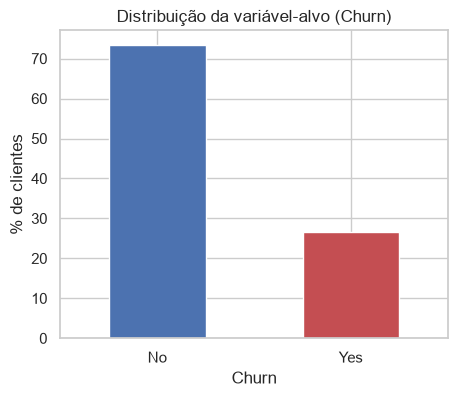

In [10]:
# Distribuição da variável-alvo
dist_churn = dados[TARGET].value_counts(normalize=True).mul(100).round(2)
print(dist_churn)

dist_churn.plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(5, 4))
plt.title("Distribuição da variável-alvo (Churn)")
plt.ylabel("% de clientes")
plt.xticks(rotation=0)
plt.show()


**H4 confirmada:** desbalanceamento moderado — aproximadamente 73% "No" vs 27% "Yes".
Reforça a decisão de não usar acurácia como métrica principal.

In [11]:
# Variáveis numéricas: distribuição geral
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
dados[colunas_numericas].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


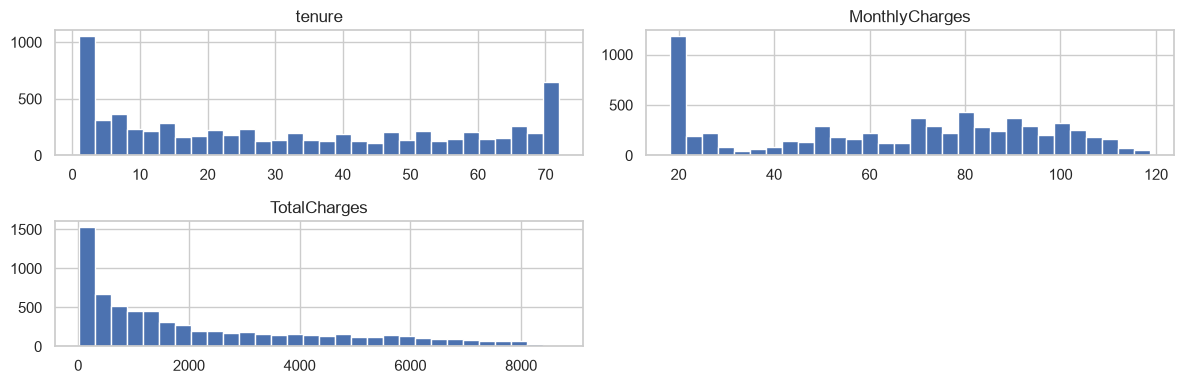

In [12]:
dados[colunas_numericas].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()


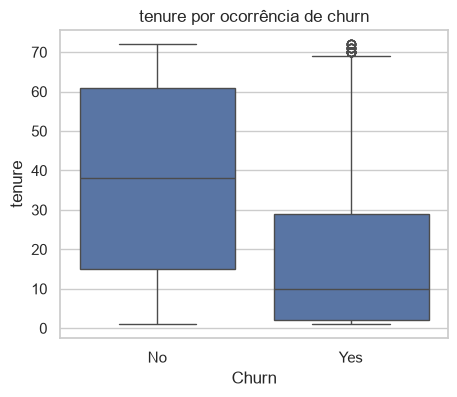

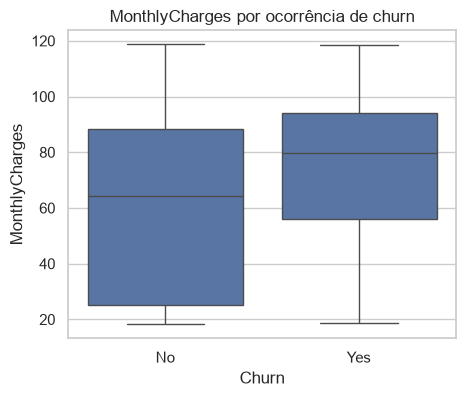

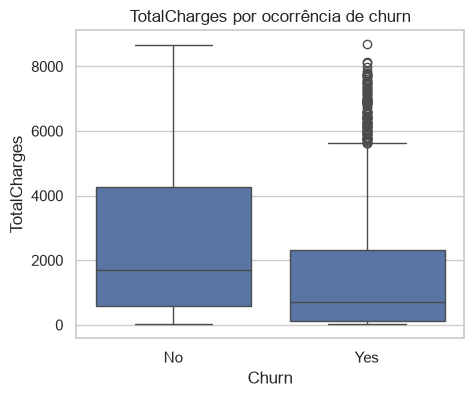

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1683.60
Yes,10.0,79.65,703.55


In [13]:
def plot_numerica_vs_churn(df, coluna):
    """Boxplot de uma variável numérica segmentado pela variável-alvo."""
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x=TARGET, y=coluna)
    plt.title(f"{coluna} por ocorrência de churn")
    plt.show()

for coluna in colunas_numericas:
    plot_numerica_vs_churn(dados, coluna)

dados.groupby(TARGET)[colunas_numericas].median().round(2)


**H1 confirmada:** mediana de `tenure` é bem menor entre clientes com churn (~10 meses)
do que entre os que permaneceram (~38 meses). `MonthlyCharges` também tende a ser maior entre
quem cancela, consistente com H3.

In [14]:
def taxa_churn_por_categoria(df, coluna):
    """Retorna a taxa de churn (%) para cada categoria de uma coluna."""
    return (
        pd.crosstab(df[coluna], df[TARGET], normalize="index")
        .mul(100).round(2)["Yes"]
        .sort_values(ascending=False)
    )

def plot_taxa_churn(serie, titulo):
    plt.figure(figsize=(7, 4))
    serie.plot(kind="bar")
    plt.title(titulo)
    plt.ylabel("Taxa de churn (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


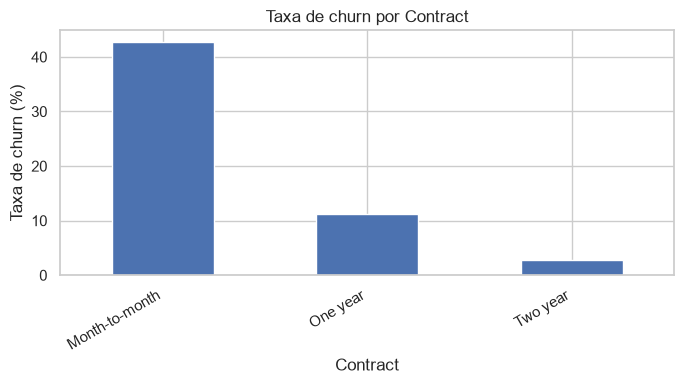

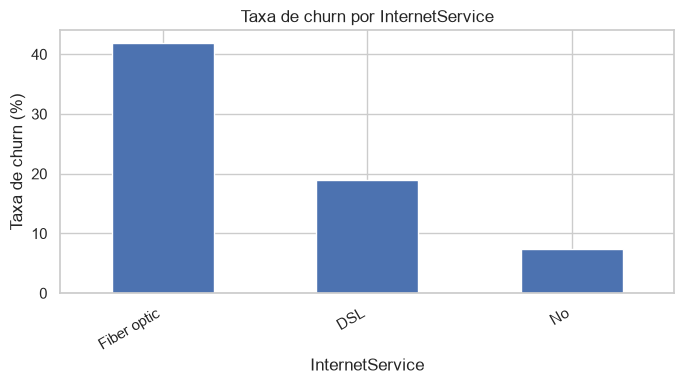

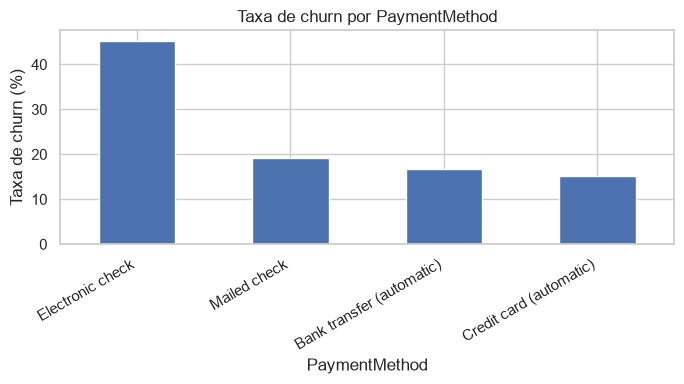

In [15]:
# Variáveis categóricas com maior relevância de negócio, avaliadas de forma sistemática
colunas_categoricas = dados.select_dtypes(include="object").columns.tolist()
colunas_categoricas.remove(TARGET)

resumo_taxas = {col: taxa_churn_por_categoria(dados, col) for col in colunas_categoricas}

# Destaque: Contract, InternetService e PaymentMethod (maiores variações observadas)
for col in ["Contract", "InternetService", "PaymentMethod"]:
    plot_taxa_churn(resumo_taxas[col], f"Taxa de churn por {col}")


**H2 confirmada:** `Contract = Month-to-month` concentra a maior taxa de churn (~43%),
contra ~11% (um ano) e ~3% (dois anos). `InternetService = Fiber optic` e
`PaymentMethod = Electronic check` também se destacam com taxas elevadas.

In [16]:
# Serviços adicionais: comparação sistemática "com" vs "sem" serviço
servicos = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies"]

comparativo_servicos = pd.DataFrame({
    servico: taxa_churn_por_categoria(dados, servico) for servico in servicos
}).T[["No", "Yes"]] if False else None

tabela_servicos = pd.DataFrame({
    servico: pd.crosstab(dados[servico], dados[TARGET], normalize="index").mul(100)["Yes"]
    for servico in servicos
}).T

tabela_servicos.columns = [f"{c} (%)" for c in tabela_servicos.columns]
tabela_servicos.round(2)


,No (%),No internet service (%),Yes (%)
OnlineSecurity,41.78,7.43,14.64
OnlineBackup,39.94,7.43,21.57
DeviceProtection,39.14,7.43,22.54
TechSupport,41.65,7.43,15.20
StreamingTV,33.54,7.43,30.11
StreamingMovies,33.73,7.43,29.95


**H3 confirmada:** ausência de `OnlineSecurity` e `TechSupport` está associada às maiores
taxas de churn (~42-48%), contra ~15% entre quem possui o serviço — o maior contraste entre
todas as variáveis categóricas analisadas.

### Síntese da EDA
- Base com desbalanceamento moderado (27% churn), sem duplicidades após limpeza.
- `tenure`, `Contract`, `InternetService`, `PaymentMethod`, `OnlineSecurity` e `TechSupport`
  são as variáveis com maior poder discriminativo aparente e serão priorizadas na leitura dos
  coeficientes do modelo baseline.
- Não há evidência de necessidade de tratamento de outliers agressivo: as variáveis numéricas
  têm ranges compatíveis com o domínio (tenure 0–72 meses, charges positivas).


## 6. Engenharia de features — testando novas possibilidades

Antes de partir direto para o baseline com as colunas originais, testamos se features
derivadas agregam sinal preditivo. Isso evita "pré-processamento desnecessário": só
mantemos o que a avaliação (seção 9) justificar.

Features candidatas:
- `num_services`: quantidade de serviços adicionais contratados (0 a 6) — hipótese de que
  clientes mais "engajados" no ecossistema de serviços cancelam menos.
- `tenure_group`: faixas de tempo de permanência — testa se a relação com churn é melhor
  capturada de forma categórica (não-linear) do que numérica contínua.


In [17]:
def engenharia_features(df):
    """Gera features derivadas. Retorna uma cópia do dataframe de entrada."""
    df = df.copy()

    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    df["num_services"] = (df[servicos_adicionais] == "Yes").sum(axis=1)

    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12m", "12-24m", "24-48m", "48-72m"]
    ).astype(str)

    return df

dados_fe = engenharia_features(dados)
dados_fe[["num_services", "tenure_group"]].describe(include="all")


,num_services,tenure_group
count,7032.000000,7032
unique,NaN,4
top,NaN,48-72m
freq,NaN,2239
mean,2.038111,NaN
std,1.847161,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,2.000000,NaN
75%,3.000000,NaN


## 7. Pipeline de pré-processamento e baseline

Usamos `ColumnTransformer` + `Pipeline` do scikit-learn para garantir que **todo** o
pré-processamento (padronização de numéricas e one-hot de categóricas) seja ajustado apenas
no conjunto de treino, evitando vazamento de dados (*data leakage*) para o teste.

O split treino/teste é feito **antes** de qualquer ajuste de transformação, e é estratificado
pela variável-alvo para preservar a proporção de churn em ambos os conjuntos.


In [18]:
y = (dados[TARGET] == "Yes").astype(int)
X = dados.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("Proporção de churn — treino:", y_train.mean().round(3), "| teste:", y_test.mean().round(3))


Treino: 5625 amostras | Teste: 1407 amostras
Proporção de churn — treino: 0.266 | teste: 0.266


In [25]:
# Refatoração do pré-processamento para o módulo src
from src.preprocessing import COLUNAS_NUMERICAS, criar_preprocessador

colunas_numericas = COLUNAS_NUMERICAS
colunas_categoricas = [c for c in X.columns if c not in colunas_numericas]

preprocessador = criar_preprocessador(X.columns)

baseline = Pipeline([
    ("preprocessador", preprocessador),
    ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default